In [ ]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

c:\Users\Gayatri_dasari\OneDrive\Desktop\langgraph projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [10]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [11]:
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add]
    final: str

In [12]:
llm = ChatGroq(model="llama-3.1-8b-instant")

In [13]:
def orchestrator(state: State) -> dict:
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {'plan': plan}

In [14]:
def fanout(state: State):
    return [Send("worker", {'task': task, 'topic':state['topic'], 'plan': state['plan']})
            for task in state['plan'].tasks]

In [16]:
def worker(payload: dict) -> dict:
    task = payload['task']
    topic = payload['topic']
    plan = payload['plan']

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {'sections':[section_md]}

In [17]:
from pathlib import Path

def reducer(state: State) -> dict:
    title = state['plan'].blog_title
    body = "\n\n.join(State['sections]).strip()"

    final_md = f"# {title}\n\n{body}\n"

    filename = title.lower().replace(" ","_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md,encoding="utf-8")

    return {'final':final_md}

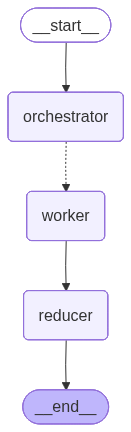

In [19]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker",worker)
g.add_node("reducer",reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator",fanout,['worker'])
g.add_edge('worker','reducer')
g.add_edge('reducer',END)

app = g.compile()

app

In [21]:
out = app.invoke({'topic':'Write a blog on Self Attention','sections':[]})

In [23]:
out

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self-Attention: A Key Component of Deep Learning', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Definition and importance of self-attention in deep learning models'), Task(id=2, title='How Self-Attention Works', brief='Explanation of the self-attention mechanism and its components'), Task(id=3, title='Types of Self-Attention', brief='Discussion of different types of self-attention mechanisms'), Task(id=4, title='Applications of Self-Attention', brief='Real-world applications of self-attention in natural language processing and computer vision'), Task(id=5, title='Challenges and Limitations of Self-Attention', brief='Discussion of the challenges and limitations of self-attention mechanisms'), Task(id=6, title='Future Directions of Self-Attention', brief='Potential future directions and advancements in self-attention research'), Task(id=7, title='Conclusion and Final Thoughts', brief='